# Fusion stacking SHAP summary plot

This notebook makes a model-agnostic SHAP-style global beeswarm plot for the final RF stacking fusion model. Because the installed environment does not include the `shap` package and the stacking model has only four input features, we compute exact Shapley values by enumerating all feature subsets and using the training cohort as the background distribution.

In [1]:

# ============================================================
# 1. Imports and paths
# ============================================================

import os
import json
import math
import itertools
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import font_manager
from sklearn.metrics import roc_auc_score

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

model_root = Path('/host/d/projects/Habitats/models/Prognosis')
fusion_root = model_root / 'fusion'
stacking_root = fusion_root / 'stacking'
results_out_dir = Path('/host/d/projects/Habitats/results/SHAP')
results_out_dir.mkdir(parents=True, exist_ok=True)

fusion_probability_path = fusion_root / 'fusion_final_selection_probabilities.xlsx'
stacking_final_selection_dir = stacking_root / 'final_selections' / 'RF'
stacking_manifest_path = stacking_final_selection_dir / 'train_selected_settings_manifest.json'

# This is the final selected RF stacking experiment in the current final-selection output.
# It was verified against train_selected_settings_predictions.xlsx.
stacking_model_path = stacking_root / 'RF' / 'random20' / 'alltraindata_model.joblib'
train_prediction_check_path = stacking_final_selection_dir / 'train_selected_settings_predictions.xlsx'

summary_pdf_path = results_out_dir / 'fusion_stacking_SHAP_summary.pdf'
summary_values_path = results_out_dir / 'fusion_stacking_SHAP_values_train.xlsx'
importance_table_path = results_out_dir / 'fusion_stacking_SHAP_importance_train.xlsx'

# ------------------------------------------------------------
# Figure style
# ------------------------------------------------------------

times_font_paths = [
    '/host/c/Windows/Fonts/times.ttf',
    '/host/c/Windows/Fonts/timesbd.ttf',
    '/host/c/Windows/Fonts/timesi.ttf',
    '/host/c/Windows/Fonts/timesbi.ttf',
]
for font_path in times_font_paths:
    if os.path.isfile(font_path):
        font_manager.fontManager.addfont(font_path)

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

print('Fusion probability table:', fusion_probability_path)
print('Stacking model:', stacking_model_path)
print('Output PDF:', summary_pdf_path)

def save_pdf_and_ppt_safe_svg(fig, pdf_path, **kwargs):
    """Save the normal PDF plus a PPT-friendly SVG copy.

    The SVG suffix is `_ppt_safe.svg`, so original PDF manuscript outputs stay unchanged.
    """
    pdf_path = Path(pdf_path)
    fig.savefig(pdf_path, **kwargs)
    svg_path = pdf_path.with_name(pdf_path.stem + '_ppt_safe.svg')
    fig.savefig(svg_path, format='svg', **kwargs)
    return svg_path


Fusion probability table: /host/d/projects/Habitats/models/Prognosis/fusion/fusion_final_selection_probabilities.xlsx
Stacking model: /host/d/projects/Habitats/models/Prognosis/fusion/stacking/RF/random20/alltraindata_model.joblib
Output PDF: /host/d/projects/Habitats/results/SHAP/fusion_stacking_SHAP_summary.pdf


In [2]:

# ============================================================
# 2. Load train cohort fusion probabilities and final RF model
# ============================================================

feature_columns = [
    'prob_clinical',
    'prob_whole_image',
    'prob_habitats_avg',
    'prob_dl_3d_ml_all',
]

feature_display_names = {
    'prob_clinical': 'Clinical',
    'prob_whole_image': 'C-radiomics',
    'prob_habitats_avg': 'H-radiomics',
    'prob_dl_3d_ml_all': 'DL_3D',
}

fusion_df = pd.read_excel(fusion_probability_path)

required_columns = ['Patient_set', 'Patient_index', 'Prognosis_label', 'dataset'] + feature_columns
missing_columns = [col for col in required_columns if col not in fusion_df.columns]
if missing_columns:
    raise KeyError(f'Missing required columns in fusion table: {missing_columns}')

# Use the training/CV cohort for the global SHAP summary plot.
train_df = fusion_df[fusion_df['dataset'].astype(str).str.lower().eq('cv')].copy().reset_index(drop=True)
if train_df.shape[0] == 0:
    raise RuntimeError('No training/CV rows found in fusion probability table.')

X_train = train_df[feature_columns].astype(float).to_numpy()
y_train = train_df['Prognosis_label'].astype(int).to_numpy()

stacking_model = joblib.load(stacking_model_path)
train_prob = stacking_model.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, train_prob)

print('Train/CV cases:', train_df.shape[0])
print('Input feature shape:', X_train.shape)
print('Stacking train AUC from loaded model:', round(train_auc, 4))
print('Prediction range:', float(train_prob.min()), float(train_prob.max()))

# Sanity check: loaded alltraindata_model should match saved train predictions.
if train_prediction_check_path.is_file():
    saved_pred = pd.read_excel(train_prediction_check_path)
    pred_col_candidates = [col for col in saved_pred.columns if col.startswith('prob_train_')]
    if len(pred_col_candidates) > 0:
        pred_col = pred_col_candidates[0]
        check_df = train_df[['Patient_set', 'Patient_index']].copy()
        check_df['loaded_model_probability'] = train_prob
        check_df = check_df.merge(
            saved_pred[['Patient_set', 'Patient_index', pred_col]],
            on=['Patient_set', 'Patient_index'],
            how='left',
        )
        max_abs_diff = np.nanmax(np.abs(check_df['loaded_model_probability'] - check_df[pred_col]))
        print('Max absolute difference versus saved train predictions:', max_abs_diff)


Train/CV cases: 188
Input feature shape: (188, 4)
Stacking train AUC from loaded model: 0.9511
Prediction range: 0.04023557025676824 0.8893210635359723
Max absolute difference versus saved train predictions: 0.15107671523263608


In [3]:

# ============================================================
# 3. Exact model-agnostic Shapley values for four input features
# ============================================================

# We use the training cohort itself as the background distribution.
# For a subset S, v(S) = average prediction after fixing x_S and replacing
# the remaining features with background values.
# With only four features, exact enumeration is fast and avoids requiring shap.

M = X_train.shape[1]
feature_indices = tuple(range(M))
background = X_train.copy()


def predict_positive_probability(X):
    return stacking_model.predict_proba(np.asarray(X, dtype=float))[:, 1]


baseline_probability = float(np.mean(predict_positive_probability(background)))
print('Baseline E[f(X)] on train background:', baseline_probability)


def subset_value_for_one_case(x, subset):
    # Return v(S) for one case x and one subset of feature indices.
    mixed = background.copy()
    if len(subset) > 0:
        mixed[:, list(subset)] = x[list(subset)]
    return float(np.mean(predict_positive_probability(mixed)))


def exact_shapley_for_one_case(x):
    # Exact Shapley values by enumerating all subsets for M=4 features.
    subset_values = {}
    for r in range(M + 1):
        for subset in itertools.combinations(feature_indices, r):
            subset_values[subset] = subset_value_for_one_case(x, subset)

    phi = np.zeros(M, dtype=float)
    factorial_M = math.factorial(M)
    for i in feature_indices:
        other_features = [j for j in feature_indices if j != i]
        for r in range(M):
            for subset_without_i in itertools.combinations(other_features, r):
                subset_without_i = tuple(sorted(subset_without_i))
                subset_with_i = tuple(sorted(subset_without_i + (i,)))
                weight = math.factorial(r) * math.factorial(M - r - 1) / factorial_M
                phi[i] += weight * (subset_values[subset_with_i] - subset_values[subset_without_i])
    return phi


shap_values = np.zeros_like(X_train, dtype=float)
for row_i, x in enumerate(X_train):
    if row_i == 0 or (row_i + 1) % 25 == 0 or row_i == X_train.shape[0] - 1:
        print(f'Computing Shapley values: {row_i + 1}/{X_train.shape[0]}')
    shap_values[row_i, :] = exact_shapley_for_one_case(x)

# Additivity check: baseline + sum(phi) should equal model probability.
reconstructed_prob = baseline_probability + shap_values.sum(axis=1)
max_additivity_error = float(np.max(np.abs(reconstructed_prob - train_prob)))
print('Max additivity error:', max_additivity_error)

shap_df = train_df[['Patient_set', 'Patient_index', 'Prognosis_label', 'split', 'fold']].copy()
shap_df['stacking_probability'] = train_prob
for col_i, col in enumerate(feature_columns):
    shap_df[feature_display_names[col] + '_value'] = X_train[:, col_i]
    shap_df[feature_display_names[col] + '_SHAP'] = shap_values[:, col_i]
shap_df.to_excel(summary_values_path, index=False)

importance_df = pd.DataFrame({
    'Feature': [feature_display_names[col] for col in feature_columns],
    'Mean_abs_SHAP': np.mean(np.abs(shap_values), axis=0),
    'Mean_SHAP': np.mean(shap_values, axis=0),
}).sort_values('Mean_abs_SHAP', ascending=False).reset_index(drop=True)
importance_df.to_excel(importance_table_path, index=False)

display(importance_df)
print('Saved SHAP values:', summary_values_path)
print('Saved SHAP importance:', importance_table_path)


Baseline E[f(X)] on train background: 0.37248694940249594
Computing Shapley values: 1/188


Computing Shapley values: 25/188


Computing Shapley values: 50/188


Computing Shapley values: 75/188


Computing Shapley values: 100/188


...

Computing Shapley values: 150/188


Computing Shapley values: 175/188


Computing Shapley values: 188/188
Max additivity error: 3.3306690738754696e-16


,Feature,Mean_abs_SHAP,Mean_SHAP
0,DL_3D,0.141243,2.952721e-18
1,H-radiomics,0.108155,9.448707e-18
2,C-radiomics,0.064087,3.543265e-18
3,Clinical,0.022501,7.381802e-18


Saved SHAP values: /host/d/projects/Habitats/results/SHAP/fusion_stacking_SHAP_values_train.xlsx
Saved SHAP importance: /host/d/projects/Habitats/results/SHAP/fusion_stacking_SHAP_importance_train.xlsx


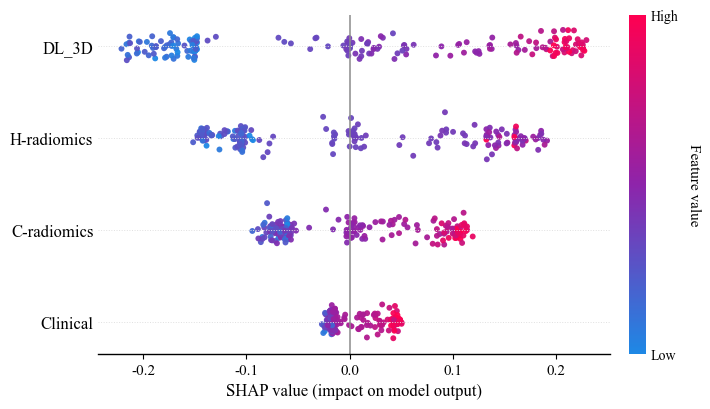

Saved SHAP summary plot: /host/d/projects/Habitats/results/SHAP/fusion_stacking_SHAP_summary.pdf


In [4]:

# ============================================================
# 4. Beeswarm-style SHAP summary plot
# ============================================================

# Plot features by global importance, similar to the example figure.
feature_order_names = importance_df['Feature'].tolist()
name_to_index = {feature_display_names[col]: i for i, col in enumerate(feature_columns)}
ordered_indices = [name_to_index[name] for name in feature_order_names]

# Red = high feature value, blue = low feature value, with a purple middle.
shap_cmap = mcolors.LinearSegmentedColormap.from_list(
    'blue_purple_red',
    ['#1e88e5', '#8e24aa', '#ff0051'],
)

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(7.2, 4.2))

for plot_row, feature_i in enumerate(ordered_indices):
    feature_values = X_train[:, feature_i]
    shap_feature_values = shap_values[:, feature_i]

    # Normalize colors within each feature, matching standard SHAP summary behavior.
    v_min = np.nanpercentile(feature_values, 1)
    v_max = np.nanpercentile(feature_values, 99)
    if np.isclose(v_min, v_max):
        colors_numeric = np.full_like(feature_values, 0.5, dtype=float)
    else:
        colors_numeric = np.clip((feature_values - v_min) / (v_max - v_min), 0, 1)

    # Simple beeswarm-like vertical jitter. The jitter is deterministic.
    jitter = rng.normal(loc=0.0, scale=0.075, size=feature_values.shape[0])
    y = np.full(feature_values.shape[0], plot_row, dtype=float) + jitter

    ax.scatter(
        shap_feature_values,
        y,
        c=colors_numeric,
        cmap=shap_cmap,
        vmin=0,
        vmax=1,
        s=18,
        alpha=0.95,
        edgecolors='none',
        rasterized=False,
    )

ax.axvline(0, color='0.55', linewidth=1.1)
ax.set_yticks(range(len(feature_order_names)))
ax.set_yticklabels(feature_order_names, fontsize=12)
ax.invert_yaxis()
ax.set_xlabel('SHAP value (impact on model output)', fontsize=12)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', length=0)
ax.grid(axis='y', linestyle=':', linewidth=0.7, color='0.88')
ax.grid(axis='x', visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)

sm = plt.cm.ScalarMappable(cmap=shap_cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.035, fraction=0.045)
cbar.set_label('Feature value', fontsize=11, rotation=270, labelpad=16)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'])
cbar.ax.tick_params(labelsize=10, length=0)
cbar.outline.set_visible(False)

fig.tight_layout()
save_pdf_and_ppt_safe_svg(fig, summary_pdf_path, bbox_inches='tight')
plt.show()

print('Saved SHAP summary plot:', summary_pdf_path)


## Section 2. Find individual waterfall candidate cases

This section is intentionally independent from the SHAP computation above. It reads the saved train-cohort SHAP value table, finds cases where all four modalities push the final stacking prediction upward or downward, and saves candidate lists for later individual waterfall plotting.

In [5]:

# ============================================================
# Section 2. Find individual waterfall candidate cases
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

results_out_dir = Path('/host/d/projects/Habitats/results/SHAP')
results_out_dir.mkdir(parents=True, exist_ok=True)
shap_values_path = results_out_dir / 'fusion_stacking_SHAP_values_train.xlsx'
candidate_out_path = results_out_dir / 'individual_waterfall_candidates.xlsx'

print('Input SHAP values:', shap_values_path)
print('Output candidates:', candidate_out_path)

# ------------------------------------------------------------
# Load SHAP values
# ------------------------------------------------------------

if not shap_values_path.is_file():
    raise FileNotFoundError(
        f'SHAP values file not found: {shap_values_path}. '
        'Please run Section 1 of SHAP.ipynb first.'
    )

shap_df = pd.read_excel(shap_values_path)

shap_columns = [
    'Clinical_SHAP',
    'C-radiomics_SHAP',
    'H-radiomics_SHAP',
    'DL_3D_SHAP',
]

value_columns = [
    'Clinical_value',
    'C-radiomics_value',
    'H-radiomics_value',
    'DL_3D_value',
]

required_columns = [
    'Patient_set',
    'Patient_index',
    'Prognosis_label',
    'fold',
    'stacking_probability',
] + shap_columns + value_columns

missing_columns = [col for col in required_columns if col not in shap_df.columns]
if missing_columns:
    raise KeyError(f'Missing expected columns in SHAP value table: {missing_columns}')

# ------------------------------------------------------------
# Candidate rules
# ------------------------------------------------------------

# all_push_up: all four modalities have positive SHAP contribution.
# all_push_down: all four modalities have negative SHAP contribution.
all_push_up_mask = (shap_df[shap_columns] > 0).all(axis=1)
all_push_down_mask = (shap_df[shap_columns] < 0).all(axis=1)

# Candidate waterfall examples should also have ordered absolute impact:
# DL_3D >= H-radiomics > C-radiomics > Clinical.
impact_order_mask = (
    (shap_df['DL_3D_SHAP'].abs() >= shap_df['H-radiomics_SHAP'].abs())
    & (shap_df['H-radiomics_SHAP'].abs() > shap_df['C-radiomics_SHAP'].abs())
    & (shap_df['C-radiomics_SHAP'].abs() > shap_df['Clinical_SHAP'].abs())
)

all_push_up_mask = all_push_up_mask & impact_order_mask
all_push_down_mask = all_push_down_mask & impact_order_mask

base_columns = [
    'Candidate_type',
    'Patient_set',
    'Patient_index',
    'Prognosis_label',
    'fold',
    'stacking_probability',
]

output_feature_columns = []
for feature_name in ['Clinical', 'C-radiomics', 'H-radiomics', 'DL_3D']:
    output_feature_columns.extend([
        f'{feature_name}_value',
        f'{feature_name}_SHAP',
    ])


def build_candidate_df(input_df, candidate_type):
    df = input_df.copy()
    df.insert(0, 'Candidate_type', candidate_type)
    df['SHAP_sum'] = df[shap_columns].sum(axis=1)
    df['abs_SHAP_sum'] = df[shap_columns].abs().sum(axis=1)
    df['min_abs_SHAP'] = df[shap_columns].abs().min(axis=1)
    df['Impact_order'] = 'DL_3D >= H-radiomics > C-radiomics > Clinical'

    keep_columns = base_columns + output_feature_columns + [
        'SHAP_sum',
        'abs_SHAP_sum',
        'min_abs_SHAP',
        'Impact_order',
    ]
    return df[keep_columns]


all_push_up_df = build_candidate_df(
    shap_df.loc[all_push_up_mask],
    'all_push_up',
)

all_push_down_df = build_candidate_df(
    shap_df.loc[all_push_down_mask],
    'all_push_down',
)

# Sort so the most useful waterfall examples are near the top.
# For all_push_up, prefer high final probability and strong total SHAP magnitude.
# For all_push_down, prefer low final probability and strong total SHAP magnitude.
all_push_up_df = all_push_up_df.sort_values(
    ['stacking_probability', 'abs_SHAP_sum'],
    ascending=[False, False],
).reset_index(drop=True)

all_push_down_df = all_push_down_df.sort_values(
    ['stacking_probability', 'abs_SHAP_sum'],
    ascending=[True, False],
).reset_index(drop=True)

candidate_all_df = pd.concat(
    [all_push_up_df, all_push_down_df],
    ignore_index=True,
)

# ------------------------------------------------------------
# Save Excel workbook
# ------------------------------------------------------------

with pd.ExcelWriter(candidate_out_path, engine='openpyxl') as writer:
    candidate_all_df.to_excel(writer, sheet_name='all_candidates', index=False)
    all_push_up_df.to_excel(writer, sheet_name='all_push_up', index=False)
    all_push_down_df.to_excel(writer, sheet_name='all_push_down', index=False)

print('Total train cases:', shap_df.shape[0])
print('All-push-up cases:', all_push_up_df.shape[0])
print('All-push-down cases:', all_push_down_df.shape[0])
print('Saved:', candidate_out_path)

print()
print('Top all-push-up candidates:')
display(all_push_up_df.head(10))

print()
print('Top all-push-down candidates:')
display(all_push_down_df.head(10))

Input SHAP values: /host/d/projects/Habitats/results/SHAP/fusion_stacking_SHAP_values_train.xlsx
Output candidates: /host/d/projects/Habitats/results/SHAP/individual_waterfall_candidates.xlsx
Total train cases: 188
All-push-up cases: 14
All-push-down cases: 26
Saved: /host/d/projects/Habitats/results/SHAP/individual_waterfall_candidates.xlsx

Top all-push-up candidates:


,Candidate_type,Patient_set,Patient_index,Prognosis_label,fold,stacking_probability,Clinical_value,Clinical_SHAP,C-radiomics_value,C-radiomics_SHAP,H-radiomics_value,H-radiomics_SHAP,DL_3D_value,DL_3D_SHAP,SHAP_sum,abs_SHAP_sum,min_abs_SHAP,Impact_order
0,all_push_up,set_2,137,1,0,0.889321,0.576753,0.039915,0.463246,0.107069,0.405166,0.159939,0.786331,0.209911,0.516834,0.516834,0.039915,DL_3D >= H-radiomics > C-radiomics > Clinical
1,all_push_up,set_2,47,1,4,0.889109,0.674118,0.042278,0.464414,0.106595,1.000000,0.159390,0.934826,0.208359,0.516622,0.516622,0.042278,DL_3D >= H-radiomics > C-radiomics > Clinical
2,all_push_up,set_2,209,1,0,0.889109,0.669655,0.042278,0.399375,0.102486,0.667056,0.159390,0.890800,0.212468,0.516622,0.516622,0.042278,DL_3D >= H-radiomics > C-radiomics > Clinical
3,all_push_up,set_2,195,1,0,0.888416,0.556594,0.038482,0.522019,0.107415,0.633531,0.161026,0.976223,0.209006,0.515929,0.515929,0.038482,DL_3D >= H-radiomics > C-radiomics > Clinical
4,all_push_up,set_1,78,1,3,0.886330,0.620100,0.042609,0.318639,0.087124,0.322881,0.161076,0.954746,0.223034,0.513843,0.513843,0.042609,DL_3D >= H-radiomics > C-radiomics > Clinical
5,all_push_up,set_2,146,1,4,0.885966,0.557120,0.037882,0.464182,0.111614,0.353727,0.167409,0.698685,0.196575,0.513479,0.513479,0.037882,DL_3D >= H-radiomics > C-radiomics > Clinical
6,all_push_up,set_1,147,1,0,0.885019,0.535606,0.032876,0.318524,0.091517,0.429158,0.169295,0.754348,0.218844,0.512532,0.512532,0.032876,DL_3D >= H-radiomics > C-radiomics > Clinical
7,all_push_up,set_2,149,1,3,0.884088,0.527844,0.031471,0.511976,0.107194,0.342789,0.161479,0.918077,0.211457,0.511601,0.511601,0.031471,DL_3D >= H-radiomics > C-radiomics > Clinical
8,all_push_up,set_1,91,1,3,0.881944,0.616262,0.042710,0.315991,0.081130,0.371736,0.164011,0.965691,0.221607,0.509457,0.509457,0.042710,DL_3D >= H-radiomics > C-radiomics > Clinical
9,all_push_up,set_2,153,1,1,0.870039,0.488976,0.016647,0.394550,0.108836,0.347941,0.165692,0.727736,0.206377,0.497552,0.497552,0.016647,DL_3D >= H-radiomics > C-radiomics > Clinical



Top all-push-down candidates:


,Candidate_type,Patient_set,Patient_index,Prognosis_label,fold,stacking_probability,Clinical_value,Clinical_SHAP,C-radiomics_value,C-radiomics_SHAP,H-radiomics_value,H-radiomics_SHAP,DL_3D_value,DL_3D_SHAP,SHAP_sum,abs_SHAP_sum,min_abs_SHAP,Impact_order
0,all_push_down,set_2,102,0,2,0.040236,0.417706,-0.017360,0.000004,-0.060375,0.122447,-0.104908,0.033441,-0.149608,-0.332251,0.332251,0.017360,DL_3D >= H-radiomics > C-radiomics > Clinical
1,all_push_down,set_1,126,0,2,0.040336,0.392532,-0.018211,0.159217,-0.060930,0.198323,-0.102053,0.049091,-0.150957,-0.332151,0.332151,0.018211,DL_3D >= H-radiomics > C-radiomics > Clinical
2,all_push_down,set_2,23,0,4,0.040766,0.387178,-0.016990,0.001310,-0.060375,0.101234,-0.104908,0.120246,-0.149449,-0.331721,0.331721,0.016990,DL_3D >= H-radiomics > C-radiomics > Clinical
3,all_push_down,set_2,59,0,2,0.040766,0.386921,-0.016990,0.197253,-0.058850,0.149571,-0.104908,0.096887,-0.150974,-0.331721,0.331721,0.016990,DL_3D >= H-radiomics > C-radiomics > Clinical
4,all_push_down,set_2,43,0,4,0.041748,0.359947,-0.017883,0.072804,-0.060375,0.185282,-0.104010,0.035607,-0.148471,-0.330739,0.330739,0.017883,DL_3D >= H-radiomics > C-radiomics > Clinical
5,all_push_down,set_2,96,0,0,0.041748,0.359309,-0.017883,0.137923,-0.059815,0.176109,-0.104010,0.138982,-0.149032,-0.330739,0.330739,0.017883,DL_3D >= H-radiomics > C-radiomics > Clinical
6,all_push_down,set_2,234,0,1,0.041748,0.281364,-0.018573,0.181994,-0.059219,0.114605,-0.104010,0.208639,-0.148937,-0.330739,0.330739,0.018573,DL_3D >= H-radiomics > C-radiomics > Clinical
7,all_push_down,set_2,155,0,4,0.041748,0.271931,-0.019037,0.031202,-0.060375,0.190385,-0.102757,0.017060,-0.148570,-0.330739,0.330739,0.019037,DL_3D >= H-radiomics > C-radiomics > Clinical
8,all_push_down,set_1,54,0,1,0.041849,0.350846,-0.018733,0.160349,-0.060930,0.208599,-0.101155,0.018811,-0.149820,-0.330638,0.330638,0.018733,DL_3D >= H-radiomics > C-radiomics > Clinical
9,all_push_down,set_1,79,0,1,0.041849,0.271485,-0.019424,0.132643,-0.061738,0.231563,-0.101155,0.274969,-0.148321,-0.330638,0.330638,0.019424,DL_3D >= H-radiomics > C-radiomics > Clinical


## Section 3. Individual waterfall plots

This standalone section draws positive and negative individual SHAP waterfall plots for the RF fusion-stacking model. It does not include MRI overlay.

In [6]:

# ============================================================
# Section 3. Individual waterfall plots
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nb
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

results_out_dir = Path('/host/d/projects/Habitats/results/SHAP')
results_out_dir.mkdir(parents=True, exist_ok=True)
shap_values_path = results_out_dir / 'fusion_stacking_SHAP_values_train.xlsx'
original_data_root = Path('/host/e/D/Data/Habitats/Jishuitan/original_data')

# MRI display settings for the two selected examples.
# No text/title will be drawn on these MRI figures.
mri_display_rot90_k = 1
mri_mask_alpha = 0.55
mri_mask_color = '#ff0033'
mri_figsize = (3.2, 3.2)

case_specs = [
    {
        'case_type': 'positive',
        'Patient_set': 'set_1',
        'Patient_index': 91,
        'bar_color': '#ff0051',
        'out_path': results_out_dir / 'fusion_stacking_SHAP_waterfall_positive.pdf',
        'mri_window_level': 1200,
        'mri_window_width': 2500,
        'mri_out_path': results_out_dir / 'fusion_stacking_MRI_overlay_positive_set_1_91.pdf',
    },
    {
        'case_type': 'negative',
        'Patient_set': 'set_2',
        'Patient_index': 59,
        'bar_color': '#1e88e5',
        'out_path': results_out_dir / 'fusion_stacking_SHAP_waterfall_negative.pdf',
        'mri_window_level': 216,
        'mri_window_width': 433,
        'mri_out_path': results_out_dir / 'fusion_stacking_MRI_overlay_negative_set_2_59.pdf',
    },
]

# Bottom-to-top order. The top row will be DL_3D, then H-radiomics,
# then C-radiomics, then Clinical.
feature_order_bottom_to_top = ['Clinical', 'C-radiomics', 'H-radiomics', 'DL_3D']

bar_text_color = 'black'
text_color = 'black'
grid_color = '#f0f0f0'
vertical_line_color = '#d8d8d8'

figsize = (8.8, 3.7)
bar_height = 0.62
arrow_tip_max = 0.020

# ------------------------------------------------------------
# Font settings
# ------------------------------------------------------------

times_font_paths = [
    '/host/c/Windows/Fonts/times.ttf',
    '/host/c/Windows/Fonts/timesbd.ttf',
    '/host/c/Windows/Fonts/timesi.ttf',
    '/host/c/Windows/Fonts/timesbi.ttf',
]
for font_path in times_font_paths:
    if os.path.isfile(font_path):
        font_manager.fontManager.addfont(font_path)

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

# ------------------------------------------------------------
# Load SHAP table
# ------------------------------------------------------------

if not shap_values_path.is_file():
    raise FileNotFoundError(f'SHAP value table not found: {shap_values_path}')

shap_df = pd.read_excel(shap_values_path)


def get_case_row(patient_set, patient_index):
    row_df = shap_df[
        (shap_df['Patient_set'].astype(str) == str(patient_set))
        & (shap_df['Patient_index'].astype(int) == int(patient_index))
    ].copy()
    if row_df.shape[0] != 1:
        raise RuntimeError(f'Expected exactly one row for {patient_set}/{patient_index}, found {row_df.shape[0]}')
    return row_df.iloc[0]


def add_waterfall_arrow(ax, x0, x1, y, height, color):
    width = abs(x1 - x0)
    if width <= 0:
        return None
    tip = min(width * 0.28, arrow_tip_max)
    y0 = y - height / 2
    y1 = y + height / 2
    ym = y

    if x1 >= x0:
        points = [
            (x0, y0),
            (x1 - tip, y0),
            (x1, ym),
            (x1 - tip, y1),
            (x0, y1),
        ]
    else:
        points = [
            (x0, y0),
            (x1 + tip, y0),
            (x1, ym),
            (x1 + tip, y1),
            (x0, y1),
        ]

    patch = Polygon(points, closed=True, facecolor=color, edgecolor=color, linewidth=0.0)
    ax.add_patch(patch)
    return patch



def find_first_existing(paths):
    for path in paths:
        if path.is_file():
            return path
    raise FileNotFoundError('None of these files exist: ' + ', '.join(str(p) for p in paths))


def load_largest_label_slice(patient_set, patient_index):
    case_dir = original_data_root / str(patient_set) / str(patient_index)
    img_path = find_first_existing([
        case_dir / 'img.nii.gz',
        case_dir / 'img.nii',
        case_dir / 'image.nii.gz',
        case_dir / 'image.nii',
    ])
    label_path = find_first_existing([
        case_dir / 'label.nii.gz',
        case_dir / 'label.nii',
        case_dir / 'mask.nii.gz',
        case_dir / 'mask.nii',
    ])

    img_arr = nb.load(str(img_path)).get_fdata()
    label_arr = nb.load(str(label_path)).get_fdata()

    if img_arr.shape != label_arr.shape:
        raise RuntimeError(f'Image/label shape mismatch for {patient_set}/{patient_index}: {img_arr.shape} vs {label_arr.shape}')
    if img_arr.ndim != 3:
        raise RuntimeError(f'Expected 3D image for {patient_set}/{patient_index}, got {img_arr.shape}')

    label_bin = label_arr > 0
    slice_areas = label_bin.sum(axis=(0, 1))
    best_slice = int(np.argmax(slice_areas))
    if slice_areas[best_slice] <= 0:
        raise RuntimeError(f'No positive label voxels found for {patient_set}/{patient_index}')

    img_slice = img_arr[:, :, best_slice]
    label_slice = label_bin[:, :, best_slice]

    if mri_display_rot90_k is not None:
        img_slice = np.rot90(img_slice, k=mri_display_rot90_k)
        label_slice = np.rot90(label_slice, k=mri_display_rot90_k)

    return img_slice, label_slice, img_path, label_path, best_slice, int(slice_areas[best_slice])


def plot_case_mri_overlay(case_spec):
    img_slice, label_slice, img_path, label_path, best_slice, label_area = load_largest_label_slice(
        case_spec['Patient_set'],
        case_spec['Patient_index'],
    )

    wl = float(case_spec['mri_window_level'])
    ww = float(case_spec['mri_window_width'])
    vmin = wl - ww / 2.0
    vmax = wl + ww / 2.0

    fig, ax = plt.subplots(figsize=mri_figsize)
    ax.imshow(img_slice, cmap='gray', vmin=vmin, vmax=vmax, interpolation='nearest')

    red_cmap = mcolors.ListedColormap([mri_mask_color])
    masked_label = np.ma.masked_where(~label_slice.astype(bool), label_slice)
    ax.imshow(masked_label, cmap=red_cmap, alpha=mri_mask_alpha, interpolation='nearest')

    # No text, no title, no ticks.
    ax.set_axis_off()
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    save_pdf_and_ppt_safe_svg(fig, case_spec['mri_out_path'], bbox_inches='tight', pad_inches=0)
    plt.close(fig)

    print('Saved MRI overlay:', case_spec['mri_out_path'])
    print('  image:', img_path)
    print('  label:', label_path)
    print('  best_slice:', best_slice, 'label_area:', label_area, 'WL/WW:', wl, ww)


def plot_case_waterfall(case_spec):
    row = get_case_row(case_spec['Patient_set'], case_spec['Patient_index'])

    values = np.array([float(row[f'{feature}_value']) for feature in feature_order_bottom_to_top], dtype=float)
    contribs = np.array([float(row[f'{feature}_SHAP']) for feature in feature_order_bottom_to_top], dtype=float)
    final_pred = float(row['stacking_probability'])
    baseline = final_pred - float(contribs.sum())

    print('\nCase:', case_spec['case_type'], case_spec['Patient_set'], case_spec['Patient_index'])
    print('Label:', int(row['Prognosis_label']))
    print('Fold:', int(row['fold']))
    print('Baseline:', baseline)
    print('Final prediction:', final_pred)
    print('SHAP sum:', contribs.sum())
    print('Additivity check:', baseline + contribs.sum() - final_pred)
    for feature, value, shap_value in zip(feature_order_bottom_to_top, values, contribs):
        print(f'{feature}: value={value:.6f}, SHAP={shap_value:+.6f}')

    starts = []
    ends = []
    current = baseline
    for contribution in contribs:
        starts.append(current)
        current = current + contribution
        ends.append(current)

    fig, ax = plt.subplots(figsize=figsize)
    y_positions = np.arange(len(feature_order_bottom_to_top))

    for y in y_positions:
        ax.axhline(y, color=grid_color, linewidth=0.9, zorder=0)

    for feature, value, contribution, x0, x1, y in zip(
        feature_order_bottom_to_top,
        values,
        contribs,
        starts,
        ends,
        y_positions,
    ):
        add_waterfall_arrow(ax, x0, x1, y, bar_height, case_spec['bar_color'])
        ax.text(
            (x0 + x1) / 2,
            y,
            f'{contribution:+.2f}',
            ha='center',
            va='center',
            fontsize=15,
            color=bar_text_color,
            fontweight='bold',
        )

    ax.axvline(baseline, color=vertical_line_color, linewidth=1.1, zorder=0)
    ax.axvline(final_pred, color=vertical_line_color, linewidth=1.1, zorder=0)

    y_labels = list(feature_order_bottom_to_top)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=15, color=text_color)

    top_text_y = len(feature_order_bottom_to_top) - 0.10
    ax.text(
        baseline,
        top_text_y,
        f'E[f(X)] = {baseline:.3f}',
        ha='center',
        va='bottom',
        fontsize=18,
        color=text_color,
        fontweight='bold',
    )
    ax.text(
        final_pred,
        top_text_y,
        f'f(x) = {final_pred:.3f}',
        ha='center',
        va='bottom',
        fontsize=18,
        color=text_color,
        fontweight='bold',
    )

    all_x = [baseline, final_pred] + starts + ends
    x_min = max(0, min(all_x) - 0.070)
    x_max = min(1, max(all_x) + 0.070)
    if x_max - x_min < 0.25:
        center = (x_min + x_max) / 2
        x_min = max(0, center - 0.17)
        x_max = min(1, center + 0.17)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.82, len(feature_order_bottom_to_top) + 0.28)
    ax.tick_params(axis='x', labelsize=15, colors=text_color, direction='out', length=3)
    ax.tick_params(axis='y', length=0, colors=text_color)
    ax.grid(axis='x', visible=False)
    ax.grid(axis='y', visible=False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_color(text_color)

    xticks = np.arange(np.ceil(x_min * 20) / 20, np.floor(x_max * 20) / 20 + 0.001, 0.05)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{x:.2f}' for x in xticks], fontsize=15, color=text_color)

    fig.tight_layout(pad=0.9)
    save_pdf_and_ppt_safe_svg(fig, case_spec['out_path'], bbox_inches='tight')
    plt.close(fig)
    print('Saved waterfall:', case_spec['out_path'])


for case_spec in case_specs:
    plot_case_waterfall(case_spec)
    plot_case_mri_overlay(case_spec)



Case: positive set_1 91
Label: 1
Fold: 3
Baseline: 0.37248694940249616
Final prediction: 0.881944017813553
SHAP sum: 0.5094570684110569
Additivity check: 0.0
Clinical: value=0.616262, SHAP=+0.042710
C-radiomics: value=0.315991, SHAP=+0.081130
H-radiomics: value=0.371736, SHAP=+0.164011
DL_3D: value=0.965691, SHAP=+0.221607


Saved waterfall: /host/d/projects/Habitats/results/SHAP/fusion_stacking_SHAP_waterfall_positive.pdf


Saved MRI overlay: /host/d/projects/Habitats/results/SHAP/fusion_stacking_MRI_overlay_positive_set_1_91.pdf
  image: /host/e/D/Data/Habitats/Jishuitan/original_data/set_1/91/img.nii.gz
  label: /host/e/D/Data/Habitats/Jishuitan/original_data/set_1/91/label.nii.gz
  best_slice: 16 label_area: 53291 WL/WW: 1200.0 2500.0

Case: negative set_2 59
Label: 0
Fold: 2
Baseline: 0.3724869494024959
Final prediction: 0.04076569992877434
SHAP sum: -0.33172124947372156
Additivity check: -1.3877787807814457e-17
Clinical: value=0.386921, SHAP=-0.016990
C-radiomics: value=0.197253, SHAP=-0.058850
H-radiomics: value=0.149571, SHAP=-0.104908
DL_3D: value=0.096887, SHAP=-0.150974


Saved waterfall: /host/d/projects/Habitats/results/SHAP/fusion_stacking_SHAP_waterfall_negative.pdf


Saved MRI overlay: /host/d/projects/Habitats/results/SHAP/fusion_stacking_MRI_overlay_negative_set_2_59.pdf
  image: /host/e/D/Data/Habitats/Jishuitan/original_data/set_2/59/img.nii.gz
  label: /host/e/D/Data/Habitats/Jishuitan/original_data/set_2/59/label.nii.gz
  best_slice: 9 label_area: 17000 WL/WW: 216.0 433.0


## Section 4. Clinical SHAP summary plot

In [7]:

# ============================================================
# Section 4. Clinical SHAP summary plot
# Model: first CV-selected clinical experiment
# ============================================================

import os
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import font_manager
from sklearn.metrics import roc_auc_score

model_root = Path('/host/d/projects/Habitats/models/Prognosis')
results_out_dir = Path('/host/d/projects/Habitats/results/SHAP')
results_out_dir.mkdir(parents=True, exist_ok=True)

for font_path in [
    '/host/c/Windows/Fonts/times.ttf',
    '/host/c/Windows/Fonts/timesbd.ttf',
    '/host/c/Windows/Fonts/timesi.ttf',
    '/host/c/Windows/Fonts/timesbi.ttf',
]:
    if os.path.isfile(font_path):
        font_manager.fontManager.addfont(font_path)

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

shap_cmap = mcolors.LinearSegmentedColormap.from_list(
    'blue_purple_red',
    ['#1e88e5', '#8e24aa', '#ff0051'],
)

ID_COLS = ['Patient_set', 'Patient_index']
META_COLS = ['Patient_set', 'Patient_index', 'Image_filepath', 'Mask_filepath', 'Prognosis_label', 'Pathologic_label', 'split', 'fold', 'Label']


def save_pdf_and_ppt_safe_svg(fig, pdf_path, **kwargs):
    pdf_path = Path(pdf_path)
    fig.savefig(pdf_path, **kwargs)
    svg_path = pdf_path.with_name(pdf_path.stem + '_ppt_safe.svg')
    fig.savefig(svg_path, format='svg', **kwargs)
    return svg_path


def load_summary(experiment_dir):
    with open(experiment_dir / 'summary.json') as f:
        return json.load(f)


def load_selected_train_matrix(experiment_dir):
    summary = load_summary(experiment_dir)
    selected_features = list(summary['selected_features'])
    table_path = Path(summary['selected_feature_table'])
    split_path = Path(summary['split_file'])

    df = pd.read_excel(table_path)

    # Whole-image and habitat selected tables do not always carry labels/split.
    if not {'Prognosis_label', 'split', 'fold'}.issubset(df.columns):
        split_df = pd.read_excel(split_path)
        keep_cols = [col for col in ['Patient_set', 'Patient_index', 'Prognosis_label', 'Pathologic_label', 'split', 'fold'] if col in split_df.columns]
        df = df.merge(split_df[keep_cols], on=['Patient_set', 'Patient_index'], how='left')

    label_col = 'Prognosis_label' if 'Prognosis_label' in df.columns else 'Label'
    if label_col not in df.columns:
        raise KeyError(f'No label column found in {table_path}')

    # Train/CV cohort: fold 0-4 or split == train.
    if 'split' in df.columns:
        train_mask = df['split'].astype(str).str.lower().eq('train')
    elif 'fold' in df.columns:
        train_mask = df['fold'].astype(int).isin([0, 1, 2, 3, 4])
    else:
        raise KeyError('No split/fold column available for train cohort selection.')

    train_df = df.loc[train_mask].copy().reset_index(drop=True)
    X = train_df[selected_features].astype(float).to_numpy()
    y = train_df[label_col].astype(int).to_numpy()
    return train_df, X, y, selected_features, summary


def predict_positive_probability(model, X):
    X = np.asarray(X, dtype=float)
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        score = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-score))
    raise TypeError('Model has neither predict_proba nor decision_function.')


def permutation_shapley_probability(model, X, background, n_permutations=30, random_state=0):
    """Approximate Shapley values on model probability using background averaging."""
    rng = np.random.default_rng(random_state)
    n, m = X.shape
    shap_values = np.zeros((n, m), dtype=float)
    baseline = float(np.mean(predict_positive_probability(model, background)))

    for row_i in range(n):
        x = X[row_i]
        if row_i == 0 or (row_i + 1) % 25 == 0 or row_i == n - 1:
            print(f'Computing permutation Shapley: {row_i + 1}/{n}')
        for _ in range(n_permutations):
            order = rng.permutation(m)
            mixed = background.copy()
            prev = float(np.mean(predict_positive_probability(model, mixed)))
            for feature_i in order:
                mixed[:, feature_i] = x[feature_i]
                current = float(np.mean(predict_positive_probability(model, mixed)))
                shap_values[row_i, feature_i] += current - prev
                prev = current
    shap_values /= float(n_permutations)
    return baseline, shap_values


def plot_shap_summary(X, shap_values, feature_names, out_pdf_path, max_display=None, random_state=0):
    mean_abs = np.mean(np.abs(shap_values), axis=0)
    order = np.argsort(mean_abs)[::-1]
    if max_display is not None:
        order = order[:max_display]

    ordered_feature_names = [feature_names[i] for i in order]
    fig_h = max(4.2, 0.34 * len(order) + 1.4)
    fig, ax = plt.subplots(figsize=(8.8, fig_h))
    rng = np.random.default_rng(random_state)

    for plot_row, feature_i in enumerate(order):
        feature_values = X[:, feature_i]
        shap_feature_values = shap_values[:, feature_i]
        v_min = np.nanpercentile(feature_values, 1)
        v_max = np.nanpercentile(feature_values, 99)
        if np.isclose(v_min, v_max):
            colors_numeric = np.full_like(feature_values, 0.5, dtype=float)
        else:
            colors_numeric = np.clip((feature_values - v_min) / (v_max - v_min), 0, 1)
        y = np.full(feature_values.shape[0], plot_row, dtype=float) + rng.normal(0.0, 0.075, size=feature_values.shape[0])
        ax.scatter(
            shap_feature_values,
            y,
            c=colors_numeric,
            cmap=shap_cmap,
            vmin=0,
            vmax=1,
            s=18,
            alpha=0.95,
            edgecolors='none',
            rasterized=False,
        )

    ax.axvline(0, color='0.55', linewidth=1.1)
    ax.set_yticks(range(len(ordered_feature_names)))
    ax.set_yticklabels(ordered_feature_names, fontsize=9.5)
    ax.invert_yaxis()
    ax.set_xlabel('SHAP value (impact on model output)', fontsize=12)
    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', length=0)
    ax.grid(axis='y', linestyle=':', linewidth=0.7, color='0.88')
    ax.grid(axis='x', visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)

    sm = plt.cm.ScalarMappable(cmap=shap_cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.035, fraction=0.045)
    cbar.set_label('Feature value', fontsize=11, rotation=270, labelpad=16)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(['Low', 'High'])
    cbar.ax.tick_params(labelsize=10, length=0)
    cbar.outline.set_visible(False)

    fig.tight_layout()
    save_pdf_and_ppt_safe_svg(fig, out_pdf_path, bbox_inches='tight')
    plt.close(fig)

    return pd.DataFrame({
        'Feature': feature_names,
        'Mean_abs_SHAP': mean_abs,
        'Mean_SHAP': np.mean(shap_values, axis=0),
    }).sort_values('Mean_abs_SHAP', ascending=False).reset_index(drop=True)


def run_unimodal_shap(model_name, experiment_dir, output_prefix, max_display=None, n_background=50, n_permutations=30, random_state=0):
    experiment_dir = Path(experiment_dir)
    train_df, X, y, feature_names, summary = load_selected_train_matrix(experiment_dir)
    model = joblib.load(summary['alltraindata_model_path'])
    train_prob = predict_positive_probability(model, X)
    auc = roc_auc_score(y, train_prob)

    rng = np.random.default_rng(random_state)
    bg_n = min(n_background, X.shape[0])
    bg_idx = rng.choice(X.shape[0], size=bg_n, replace=False)
    background = X[bg_idx].copy()

    print('\n' + '=' * 60)
    print(model_name)
    print('Experiment:', experiment_dir)
    print('Classifier:', summary.get('classifier'))
    print('Selected feature count:', len(feature_names))
    print('Train/CV cases:', X.shape[0])
    print('Train AUC from alltraindata model:', round(auc, 4))
    print('Background size:', background.shape[0])
    print('Permutations:', n_permutations)

    baseline, shap_values = permutation_shapley_probability(
        model,
        X,
        background,
        n_permutations=n_permutations,
        random_state=random_state,
    )
    reconstructed = baseline + shap_values.sum(axis=1)
    additivity_error = np.max(np.abs(reconstructed - train_prob))
    print('Baseline:', baseline)
    print('Max additivity error:', additivity_error)

    values_df = train_df[[col for col in ['Patient_set', 'Patient_index', 'Prognosis_label', 'Label', 'split', 'fold'] if col in train_df.columns]].copy()
    values_df[f'{output_prefix}_probability'] = train_prob
    for i, feature in enumerate(feature_names):
        values_df[f'{feature}_value'] = X[:, i]
        values_df[f'{feature}_SHAP'] = shap_values[:, i]

    values_path = results_out_dir / f'{output_prefix}_SHAP_values_train.xlsx'
    importance_path = results_out_dir / f'{output_prefix}_SHAP_importance_train.xlsx'
    plot_path = results_out_dir / f'{output_prefix}_SHAP_summary.pdf'

    values_df.to_excel(values_path, index=False)
    importance_df = plot_shap_summary(
        X,
        shap_values,
        feature_names,
        plot_path,
        max_display=max_display,
        random_state=random_state,
    )
    importance_df.to_excel(importance_path, index=False)

    print('Saved plot:', plot_path)
    print('Saved values:', values_path)
    print('Saved importance:', importance_path)
    display(importance_df.head(max_display or len(importance_df)))

    return importance_df

clinical_importance_df = run_unimodal_shap(
    model_name='Clinical',
    experiment_dir=model_root / 'clinical' / 'RandomForest' / 'random30_lasso_none',
    output_prefix='clinical',
    max_display=None,
    n_background=50,
    n_permutations=40,
    random_state=1,
)



Clinical
Experiment: /host/d/projects/Habitats/models/Prognosis/clinical/RandomForest/random30_lasso_none
Classifier: RandomForest
Selected feature count: 5
Train/CV cases: 188
Train AUC from alltraindata model: 0.7558
Background size: 50
Permutations: 40
Computing permutation Shapley: 1/188


Computing permutation Shapley: 25/188


Computing permutation Shapley: 50/188


Computing permutation Shapley: 75/188


Computing permutation Shapley: 100/188


...

Computing permutation Shapley: 175/188


Computing permutation Shapley: 188/188


Baseline: 0.45668196553989937
Max additivity error: 2.220446049250313e-16


Saved plot: /host/d/projects/Habitats/results/SHAP/clinical_SHAP_summary.pdf
Saved values: /host/d/projects/Habitats/results/SHAP/clinical_SHAP_values_train.xlsx
Saved importance: /host/d/projects/Habitats/results/SHAP/clinical_SHAP_importance_train.xlsx


,Feature,Mean_abs_SHAP,Mean_SHAP
0,Tumor_transverse_diameter_mm,0.055395,-0.005495
1,Tumor_AP_diameter_mm,0.050218,-0.004077
2,Total_cholesterol,0.024592,-0.000715
3,ALP,0.023813,-0.005818
4,Pathologic_fracture_1,0.002294,0.000036


## Section 5. C-radiomics SHAP summary plot

In [8]:

# ============================================================
# Section 5. C-radiomics SHAP summary plot
# First CV-selected experiment; display top 15 SHAP-ranked features.
# ============================================================

c_radiomics_importance_df = run_unimodal_shap(
    model_name='C-radiomics',
    experiment_dir=model_root / 'whole_image' / 'SVM' / 'random0_rfe_top27',
    output_prefix='C_radiomics',
    max_display=15,
    n_background=50,
    n_permutations=25,
    random_state=2,
)



C-radiomics
Experiment: /host/d/projects/Habitats/models/Prognosis/whole_image/SVM/random0_rfe_top27
Classifier: SVM
Selected feature count: 27
Train/CV cases: 188
Train AUC from alltraindata model: 0.847
Background size: 50
Permutations: 25
Computing permutation Shapley: 1/188


Computing permutation Shapley: 25/188


Computing permutation Shapley: 50/188


Computing permutation Shapley: 75/188


Computing permutation Shapley: 100/188


...

Computing permutation Shapley: 150/188


Computing permutation Shapley: 175/188


Computing permutation Shapley: 188/188
Baseline: 0.25316162748202337
Max additivity error: 1.6653345369377348e-16


Saved plot: /host/d/projects/Habitats/results/SHAP/C_radiomics_SHAP_summary.pdf
Saved values: /host/d/projects/Habitats/results/SHAP/C_radiomics_SHAP_values_train.xlsx
Saved importance: /host/d/projects/Habitats/results/SHAP/C_radiomics_SHAP_importance_train.xlsx


,Feature,Mean_abs_SHAP,Mean_SHAP
0,log-sigma-2-0-mm-3D_glszm_GrayLevelVariance,0.041979,-0.003380
1,wavelet-HLL_glcm_Correlation,0.038914,0.001070
2,log-sigma-2-0-mm-3D_glrlm_LongRunLowGrayLevelE...,0.037552,-0.001833
3,wavelet-HLH_firstorder_Median,0.036434,0.018291
4,wavelet-HLH_glcm_Idmn,0.033724,-0.012270
5,log-sigma-2-0-mm-3D_glszm_ZoneEntropy,0.032714,0.004027
6,log-sigma-2-0-mm-3D_glszm_SizeZoneNonUniformit...,0.031775,-0.006108
7,wavelet-LLH_glrlm_RunLengthNonUniformity,0.031627,-0.006962
8,wavelet-HHL_firstorder_Maximum,0.030671,-0.002345
9,wavelet-HHH_glszm_GrayLevelNonUniformity,0.028275,0.000943


## Section 6. H-radiomics SHAP summary plot

In [9]:

# ============================================================
# Section 6. H-radiomics SHAP summary plot
# Model: first CV-selected H-radiomics experiment.
# ============================================================

h_radiomics_importance_df = run_unimodal_shap(
    model_name='H-radiomics',
    experiment_dir=model_root / 'habitats_avg' / 'SVM' / 'random40_rfe_top17',
    output_prefix='H_radiomics',
    max_display=None,
    n_background=50,
    n_permutations=25,
    random_state=3,
)



H-radiomics
Experiment: /host/d/projects/Habitats/models/Prognosis/habitats_avg/SVM/random40_rfe_top17
Classifier: SVM
Selected feature count: 17
Train/CV cases: 188
Train AUC from alltraindata model: 0.8516
Background size: 50
Permutations: 25
Computing permutation Shapley: 1/188


Computing permutation Shapley: 25/188


Computing permutation Shapley: 50/188


Computing permutation Shapley: 75/188


Computing permutation Shapley: 100/188


...

Computing permutation Shapley: 150/188


Computing permutation Shapley: 175/188


Computing permutation Shapley: 188/188
Baseline: 0.2545820591133523
Max additivity error: 3.3306690738754696e-16


Saved plot: /host/d/projects/Habitats/results/SHAP/H_radiomics_SHAP_summary.pdf
Saved values: /host/d/projects/Habitats/results/SHAP/H_radiomics_SHAP_values_train.xlsx
Saved importance: /host/d/projects/Habitats/results/SHAP/H_radiomics_SHAP_importance_train.xlsx


,Feature,Mean_abs_SHAP,Mean_SHAP
0,wavelet-HLL_glrlm_LowGrayLevelRunEmphasis,0.143485,0.011301
1,wavelet-HLL_glszm_SmallAreaLowGrayLevelEmphasis,0.091121,0.001820
2,wavelet-HHH_glrlm_LongRunHighGrayLevelEmphasis,0.090691,-0.026873
3,wavelet-HHL_gldm_DependenceNonUniformityNormal...,0.059388,-0.008417
4,wavelet-HHH_gldm_DependenceNonUniformityNormal...,0.053402,0.014668
5,original_glszm_LargeAreaEmphasis,0.048800,-0.008864
6,original_glszm_LowGrayLevelZoneEmphasis,0.040463,0.006383
7,wavelet-LLH_firstorder_Skewness,0.038172,0.010214
8,wavelet-LHH_glcm_ClusterProminence,0.033463,0.004150
9,wavelet-HHL_glcm_ClusterProminence,0.028797,-0.007627


## Section 7. DL_3D SHAP summary plot

In [10]:

# ============================================================
# Section 7. DL_3D SHAP summary plot
# Model: first CV-selected DL_3D experiment.
# ============================================================

dl_3d_importance_df = run_unimodal_shap(
    model_name='DL_3D',
    experiment_dir=model_root / 'dl_3d_ml_all' / 'LR' / 'random20_lasso_top6',
    output_prefix='DL_3D',
    max_display=None,
    n_background=50,
    n_permutations=40,
    random_state=4,
)



DL_3D
Experiment: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/LR/random20_lasso_top6
Classifier: LR
Selected feature count: 6
Train/CV cases: 188
Train AUC from alltraindata model: 0.8588
Background size: 50
Permutations: 40
Computing permutation Shapley: 1/188


Computing permutation Shapley: 25/188


Computing permutation Shapley: 50/188


Computing permutation Shapley: 75/188


Computing permutation Shapley: 100/188


Computing permutation Shapley: 125/188


Computing permutation Shapley: 150/188


Computing permutation Shapley: 175/188
Computing permutation Shapley: 188/188
Baseline: 0.40150176616670824
Max additivity error: 4.440892098500626e-16


Saved plot: /host/d/projects/Habitats/results/SHAP/DL_3D_SHAP_summary.pdf
Saved values: /host/d/projects/Habitats/results/SHAP/DL_3D_SHAP_values_train.xlsx
Saved importance: /host/d/projects/Habitats/results/SHAP/DL_3D_SHAP_importance_train.xlsx


,Feature,Mean_abs_SHAP,Mean_SHAP
0,DL_feature_001,0.175303,0.038012
1,DL_feature_012,0.091866,-0.013388
2,DL_feature_002,0.089556,-0.008204
3,DL_feature_009,0.060603,-0.001253
4,DL_feature_003,0.008312,-0.002591
5,DL_feature_004,0.003802,0.001305
